# Análisis energético con Machine Learning

Este notebook realiza:

1. Carga del dataset.
2. Validación y exploración de datos.
3. Visualizaciones básicas.
4. Preparación de variables.
5. Entrenamiento de una regresión logística y un Random Forest.
6. Evaluación con `accuracy`, `F1 macro` y matriz de confusión.
7. Exportación del pipeline entrenado como `modelo_energia.joblib`.

> Importante: las categorías del dataset son simuladas para construir el MVP. No representan una certificación energética oficial.


## 1. Configuración

El notebook funciona en Google Colab y también localmente. En Colab monta Google Drive y localiza automáticamente la carpeta `analisis-de-energia`.

Sube la carpeta completa, sin separar el notebook de `generar_dataset_energia.py`, `data/` y `models/`. Los artefactos entrenados se guardan directamente en Drive dentro de `models/`.


In [49]:
%pip install -q pandas==2.2.2 scikit-learn==1.6.1 joblib==1.5.3 matplotlib seaborn


In [50]:
from pathlib import Path
import json
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

try:
    from google.colab import drive
    drive.mount("/content/drive")
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

CURRENT_DIR = Path.cwd()
if EN_COLAB:
    MY_DRIVE = Path("/content/drive/MyDrive")
    CANDIDATOS = [
      MY_DRIVE / "Notebook Hackathon" / "analisis-de-energia",
      MY_DRIVE / "Notebook Hackathon " / "analisis-de-energia",
      MY_DRIVE / "ciencia-datos" / "analisis-de-energia",
      MY_DRIVE / "analisis-de-energia",
  ]
elif CURRENT_DIR.name == "analisis-de-energia":
    CANDIDATOS = [CURRENT_DIR]
else:
    CANDIDATOS = [
        CURRENT_DIR / "ciencia-datos" / "analisis-de-energia",
        CURRENT_DIR / "analisis-de-energia",
    ]

ANALYSIS_DIR = next(
    (ruta for ruta in CANDIDATOS if ruta.is_dir()),
    None,
)
if ANALYSIS_DIR is None:
    raise FileNotFoundError(
        "No se encontró la carpeta analisis-de-energia. "
        "Sube la carpeta completa a Mi unidad/Notebook Hackathon/."
    )

DATA_DIR = ANALYSIS_DIR / "data" / "raw"
MODEL_DIR = ANALYSIS_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DATASET_PATH = DATA_DIR / "consumo_energetico.csv"
MODEL_PATH = MODEL_DIR / "modelo_energia.joblib"
METADATA_PATH = MODEL_DIR / "metadata_modelo.json"
GENERATOR_PATH = ANALYSIS_DIR / "generar_dataset_energia.py"

print("Entorno:", "Google Colab" if EN_COLAB else "Local")
print("Carpeta del análisis:", ANALYSIS_DIR)
print("Generador encontrado:", GENERATOR_PATH.exists())
print("Dataset:", DATASET_PATH)
print("Modelo de salida:", MODEL_PATH)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Entorno: Google Colab
Carpeta del análisis: /content/drive/MyDrive/Notebook Hackathon /analisis-de-energia
Generador encontrado: True
Dataset: /content/drive/MyDrive/Notebook Hackathon /analisis-de-energia/data/raw/consumo_energetico.csv
Modelo de salida: /content/drive/MyDrive/Notebook Hackathon /analisis-de-energia/models/modelo_energia.joblib


## 2. Generación del dataset

Si el CSV ya existe, se conserva y se lee. Si no existe, se crea `data/raw` y se ejecuta el generador incluido.


In [51]:
import subprocess
import sys

if DATASET_PATH.exists():
    print("El dataset ya existe; se utilizará sin regenerarlo.")
else:
    if not GENERATOR_PATH.exists():
        raise FileNotFoundError(
            f"No existe el dataset ni el generador: {GENERATOR_PATH}"
        )
    DATASET_PATH.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(
        [
            sys.executable,
            str(GENERATOR_PATH),
            "--filas",
            "8000",
            "--salida",
            str(DATASET_PATH),
        ],
        check=True,
    )
    print("Dataset generado correctamente.")

print("Dataset disponible en:", DATASET_PATH)


El dataset ya existe; se utilizará sin regenerarlo.
Dataset disponible en: /content/drive/MyDrive/Notebook Hackathon /analisis-de-energia/data/raw/consumo_energetico.csv


## 3. Carga y validación inicial


In [52]:
df = pd.read_csv(DATASET_PATH)

print("Dimensiones:", df.shape)

display(df.head())


Dimensiones: (8000, 18)


,consumo_kwh,uso_horario_pico,cantidad_equipos,tipo_inmueble,horas_alto_consumo,cantidad_personas,area_m2,equipos_alto_consumo,horas_aire_acondicionado,consumo_mes_anterior_kwh,dias_facturados,consumo_diario,consumo_por_persona,consumo_por_m2,variacion_mensual,proporcion_equipos_alto_consumo,puntaje_ineficiencia,categoria
0,690.58,False,14,Departamento,5,7,101.0,9,4,786.35,30,23.0193,98.6543,6.8374,-0.1218,0.6429,0.2280,Eficiente
1,461.07,False,6,Casa,4,4,237.0,6,0,533.72,28,16.4668,115.2675,1.9454,-0.1361,1.0000,0.1923,Eficiente
2,454.36,True,27,Pequeno negocio,0,1,103.0,2,5,483.01,28,16.2271,454.3600,4.4113,-0.0593,0.0741,0.2075,Eficiente
3,378.04,False,13,Departamento,1,3,69.0,1,11,351.31,31,12.1948,126.0133,5.4788,0.0761,0.0769,0.1600,Eficiente
4,690.52,False,14,Casa,2,7,298.0,3,3,727.15,28,24.6614,98.6457,2.3172,-0.0504,0.2143,0.1770,Eficiente


In [53]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   consumo_kwh                      8000 non-null   float64
 1   uso_horario_pico                 8000 non-null   bool   
 2   cantidad_equipos                 8000 non-null   int64  
 3   tipo_inmueble                    8000 non-null   object 
 4   horas_alto_consumo               8000 non-null   int64  
 5   cantidad_personas                8000 non-null   int64  
 6   area_m2                          8000 non-null   float64
 7   equipos_alto_consumo             8000 non-null   int64  
 8   horas_aire_acondicionado         8000 non-null   int64  
 9   consumo_mes_anterior_kwh         8000 non-null   float64
 10  dias_facturados                  8000 non-null   int64  
 11  consumo_diario                   8000 non-null   float64
 12  consumo_por_persona 

In [54]:
display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
consumo_kwh,8000.0,NaN,NaN,NaN,775.16547,469.009857,118.39,507.6425,654.84,879.8325,5000.0
uso_horario_pico,8000,2,True,4400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cantidad_equipos,8000.0,NaN,NaN,NaN,15.04875,7.948539,3.0,9.0,14.0,20.0,39.0
tipo_inmueble,8000,3,Casa,3654,NaN,NaN,NaN,NaN,NaN,NaN,NaN
horas_alto_consumo,8000.0,NaN,NaN,NaN,7.01,4.331714,0.0,3.0,7.0,11.0,14.0
cantidad_personas,8000.0,NaN,NaN,NaN,4.810375,3.093196,1.0,2.0,4.0,6.0,15.0
area_m2,8000.0,NaN,NaN,NaN,137.260375,71.051978,30.0,79.0,119.0,193.0,299.0
equipos_alto_consumo,8000.0,NaN,NaN,NaN,4.313,2.741481,0.0,2.0,4.0,7.0,9.0
horas_aire_acondicionado,8000.0,NaN,NaN,NaN,5.946625,3.737014,0.0,3.0,6.0,9.0,12.0
consumo_mes_anterior_kwh,8000.0,NaN,NaN,NaN,792.663355,492.790623,126.39,504.77,663.76,909.31,5000.0


In [55]:
print("Valores nulos por columna:")
display(df.isna().sum().sort_values(ascending=False))

print("Duplicados:", df.duplicated().sum())
print("\nDistribución de categorías:")
display(df["categoria"].value_counts())
display(df["categoria"].value_counts(normalize=True).round(4))


Valores nulos por columna:


,0
consumo_kwh,0
uso_horario_pico,0
cantidad_equipos,0
tipo_inmueble,0
horas_alto_consumo,0
cantidad_personas,0
area_m2,0
equipos_alto_consumo,0
horas_aire_acondicionado,0
consumo_mes_anterior_kwh,0


Duplicados: 0

Distribución de categorías:


,count
categoria,
Moderado,2960
Eficiente,2640
Ineficiente,2400


,proportion
categoria,
Moderado,0.37
Eficiente,0.33
Ineficiente,0.30


## 4. Validaciones de calidad

Estas comprobaciones detectan valores imposibles o inconsistentes antes del entrenamiento.


In [56]:
validaciones = {
    "consumo_kwh_en_rango": df["consumo_kwh"].between(40, 5000).all(),
    "cantidad_equipos_positiva": (df["cantidad_equipos"] > 0).all(),
    "personas_positivas": (df["cantidad_personas"] > 0).all(),
    "area_positiva": (df["area_m2"] > 0).all(),
    "horas_alto_consumo_validas": df["horas_alto_consumo"].between(0, 24).all(),
    "horas_aire_validas": df["horas_aire_acondicionado"].between(0, 24).all(),
    "dias_facturados_validos": df["dias_facturados"].between(1, 40).all(),
}

display(pd.Series(validaciones, name="resultado"))
assert all(validaciones.values()), "El dataset contiene valores fuera de rango."


,resultado
consumo_kwh_en_rango,True
cantidad_equipos_positiva,True
personas_positivas,True
area_positiva,True
horas_alto_consumo_validas,True
horas_aire_validas,True
dias_facturados_validos,True


## 5. EDA (Analisis Exploratorio de datos)


### Correlación entre variables numericas

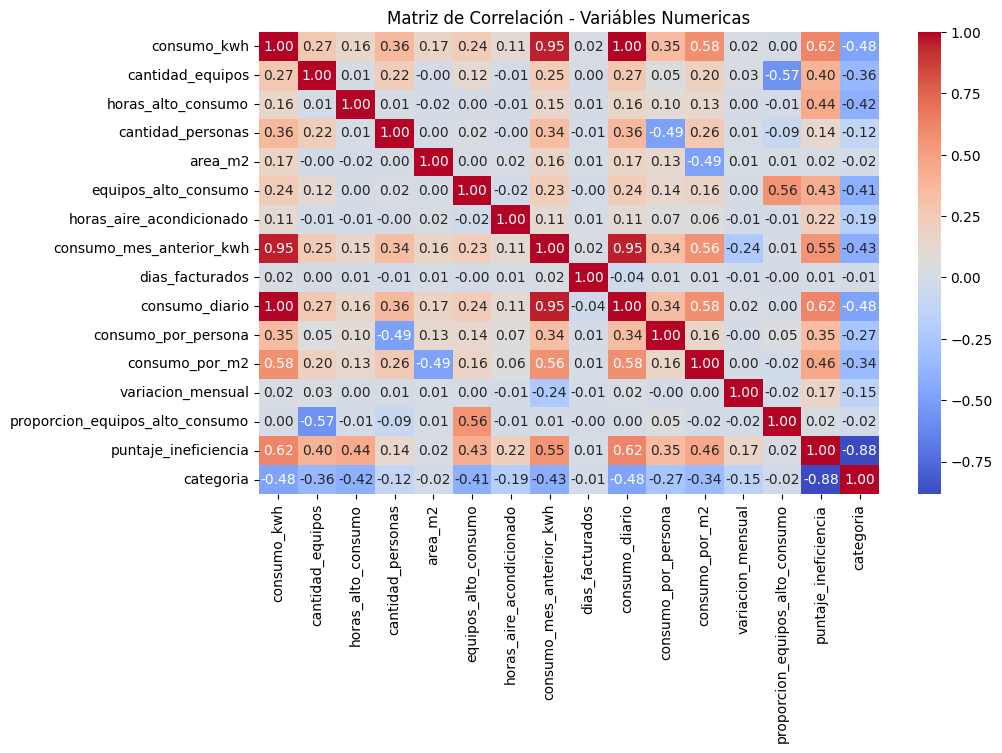

In [57]:
import seaborn as sns

df_numeric = df.select_dtypes(include=["int64", "float64"])

df_numeric["categoria"] = df["categoria"].map({"Ineficiente": 0, "Moderado": 1, "Eficiente": 2 })

corr_matrix = df_numeric.corr()

# Visualizar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Numericas")
plt.show()

In [58]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   consumo_kwh                      8000 non-null   float64
 1   uso_horario_pico                 8000 non-null   bool   
 2   cantidad_equipos                 8000 non-null   int64  
 3   tipo_inmueble                    8000 non-null   object 
 4   horas_alto_consumo               8000 non-null   int64  
 5   cantidad_personas                8000 non-null   int64  
 6   area_m2                          8000 non-null   float64
 7   equipos_alto_consumo             8000 non-null   int64  
 8   horas_aire_acondicionado         8000 non-null   int64  
 9   consumo_mes_anterior_kwh         8000 non-null   float64
 10  dias_facturados                  8000 non-null   int64  
 11  consumo_diario                   8000 non-null   float64
 12  consumo_por_persona 

In [59]:
df = df.drop(columns=["consumo_mes_anterior_kwh","puntaje_ineficiencia","consumo_diario"])

In [60]:
display(df.head())

,consumo_kwh,uso_horario_pico,cantidad_equipos,tipo_inmueble,horas_alto_consumo,cantidad_personas,area_m2,equipos_alto_consumo,horas_aire_acondicionado,dias_facturados,consumo_por_persona,consumo_por_m2,variacion_mensual,proporcion_equipos_alto_consumo,categoria
0,690.58,False,14,Departamento,5,7,101.0,9,4,30,98.6543,6.8374,-0.1218,0.6429,Eficiente
1,461.07,False,6,Casa,4,4,237.0,6,0,28,115.2675,1.9454,-0.1361,1.0000,Eficiente
2,454.36,True,27,Pequeno negocio,0,1,103.0,2,5,28,454.3600,4.4113,-0.0593,0.0741,Eficiente
3,378.04,False,13,Departamento,1,3,69.0,1,11,31,126.0133,5.4788,0.0761,0.0769,Eficiente
4,690.52,False,14,Casa,2,7,298.0,3,3,28,98.6457,2.3172,-0.0504,0.2143,Eficiente


# Mapeo de categorías

In [61]:
MAPEO_CATEGORIAS = {
    "Ineficiente": 0,
    "Moderado": 1,
    "Eficiente": 2,
}

MAPEO_CATEGORIAS_INVERSO = {
    0: "Ineficiente",
    1: "Moderado",
    2: "Eficiente",
}

### Analisis de categoria por categoria (variables categoricas)

In [62]:
df["categoria"] = df["categoria"].map(MAPEO_CATEGORIAS).astype(int)
display(df.head())

,consumo_kwh,uso_horario_pico,cantidad_equipos,tipo_inmueble,horas_alto_consumo,cantidad_personas,area_m2,equipos_alto_consumo,horas_aire_acondicionado,dias_facturados,consumo_por_persona,consumo_por_m2,variacion_mensual,proporcion_equipos_alto_consumo,categoria
0,690.58,False,14,Departamento,5,7,101.0,9,4,30,98.6543,6.8374,-0.1218,0.6429,2
1,461.07,False,6,Casa,4,4,237.0,6,0,28,115.2675,1.9454,-0.1361,1.0000,2
2,454.36,True,27,Pequeno negocio,0,1,103.0,2,5,28,454.3600,4.4113,-0.0593,0.0741,2
3,378.04,False,13,Departamento,1,3,69.0,1,11,31,126.0133,5.4788,0.0761,0.0769,2
4,690.52,False,14,Casa,2,7,298.0,3,3,28,98.6457,2.3172,-0.0504,0.2143,2


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   consumo_kwh                      8000 non-null   float64
 1   uso_horario_pico                 8000 non-null   bool   
 2   cantidad_equipos                 8000 non-null   int64  
 3   tipo_inmueble                    8000 non-null   object 
 4   horas_alto_consumo               8000 non-null   int64  
 5   cantidad_personas                8000 non-null   int64  
 6   area_m2                          8000 non-null   float64
 7   equipos_alto_consumo             8000 non-null   int64  
 8   horas_aire_acondicionado         8000 non-null   int64  
 9   dias_facturados                  8000 non-null   int64  
 10  consumo_por_persona              8000 non-null   float64
 11  consumo_por_m2                   8000 non-null   float64
 12  variacion_mensual   

### Tabla de proporción por categoria

In [64]:
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols = df.select_dtypes(include=["int64"]).columns.drop("categoria")

In [65]:
for col in categorical_cols:
    print(f"\n📌 Analisis de variable: {col}")
    display(pd.crosstab(df[col], df["categoria"], normalize="index") * 100)


📌 Analisis de variable: cantidad_equipos


categoria,0,1,2
cantidad_equipos,,,
3,5.369128,27.181208,67.449664
4,7.638889,27.777778,64.583333
5,13.421053,37.105263,49.473684
6,12.844037,39.143731,48.012232
7,16.417910,37.313433,46.268657
8,20.615385,39.076923,40.307692
9,22.318841,35.072464,42.608696
10,25.443787,34.615385,39.940828
11,19.219219,46.246246,34.534535



📌 Analisis de variable: horas_alto_consumo


categoria,0,1,2
horas_alto_consumo,,,
0,9.340659,28.388278,62.271062
1,11.722913,27.531083,60.746004
2,11.800000,35.200000,53.000000
3,13.111546,37.181996,49.706458
4,18.613139,37.956204,43.430657
5,18.933824,39.154412,41.911765
6,24.698795,41.164659,34.136546
7,28.219697,38.825758,32.954545
8,32.283465,40.748031,26.968504



📌 Analisis de variable: cantidad_personas


...

categoria,0,1,2
equipos_alto_consumo,,,
0,10.414053,31.994981,57.590966
1,13.133940,33.029909,53.836151
2,15.492958,39.820743,44.686300
3,18.218623,37.348178,44.433198
4,25.410734,38.335159,36.254107
5,31.415929,42.146018,26.438053
6,37.226277,42.944039,19.829684
7,45.682451,37.325905,16.991643
8,56.277056,32.034632,11.688312



📌 Analisis de variable: horas_aire_acondicionado


categoria,0,1,2
horas_aire_acondicionado,,,
0,17.666126,34.359806,47.974068
1,21.266234,34.415584,44.318182
2,21.936460,33.585477,44.478064
3,24.598071,38.424437,36.977492
4,25.913621,38.704319,35.382060
5,29.302326,37.209302,33.488372
6,32.427844,35.314092,32.258065
7,32.467532,34.090909,33.441558
8,34.899329,39.093960,26.006711



📌 Analisis de variable: dias_facturados


categoria,0,1,2
dias_facturados,,,
28,30.448223,36.115404,33.436373
29,28.711416,39.245468,32.043116
30,29.101067,36.008126,34.890808
31,31.722792,36.554417,31.722792


### Metodo: Qui-cuadrado (Chi-Square Test, para evaluar variables sifnificativas)

¿Existe una relación o asociación real entre estas dos variables, o la diferencia que vemos en los datos se debe simplemente al azar?

Si el  𝑝−𝑣𝑎𝑙𝑢𝑒<0.05: 𝑆𝑒 𝑟𝑒𝑐ℎ𝑎𝑧𝑎. 𝐶𝑜𝑛𝑐𝑙𝑢𝑖𝑚𝑜𝑠 𝑞𝑢𝑒 𝑠í 𝑒𝑥𝑖𝑠𝑡𝑒 𝑢𝑛𝑎 𝑟𝑒𝑙𝑎𝑐𝑖ó𝑛 𝑒𝑠𝑡𝑎𝑑í𝑠𝑡𝑖𝑐𝑎𝑚𝑒𝑛𝑡𝑒 𝑠𝑖𝑔𝑛𝑖𝑓𝑖𝑐𝑎𝑡𝑖𝑣𝑎 𝑒𝑛𝑡𝑟𝑒 𝑙𝑎𝑠 𝑣𝑎𝑟𝑖𝑎𝑏𝑙𝑒𝑠. 𝑆𝑖 𝑒𝑙 p{-value} > 0.05: No hay suficiente evidencia para rechazar. Las variables se consideran independientes.

In [66]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# Crea copia
df_rank = df.copy()

# Convertir Churn para binario
df_rank["categoria"] = df_rank["categoria"]

# Separar variables categóricas
categorical_cols = df_rank.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding temporario
le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

# Separar X e y
X_cat = df_rank[categorical_cols]
y = df_rank["categoria"]

# Aplicar teste Qui-cuadrado
chi_scores, p_values = chi2(X_cat, y)

# Criar DataFrame com ranking
chi_df = pd.DataFrame({
    "Variable": categorical_cols,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

# Ordenar por importancia
chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

chi_df

,Variable,Chi2 Score,p-value
0,tipo_inmueble,156.050949,1.300071e-34


In [67]:
significant_vars = chi_df[chi_df["p-value"] < 0.05]

print("\n✅ Variables significativas (p < 0.05):")
display(significant_vars)


✅ Variables significativas (p < 0.05):


,Variable,Chi2 Score,p-value
0,tipo_inmueble,156.050949,1.300071e-34


## 6. Exploración visual


### Distrubución del consumo mensual

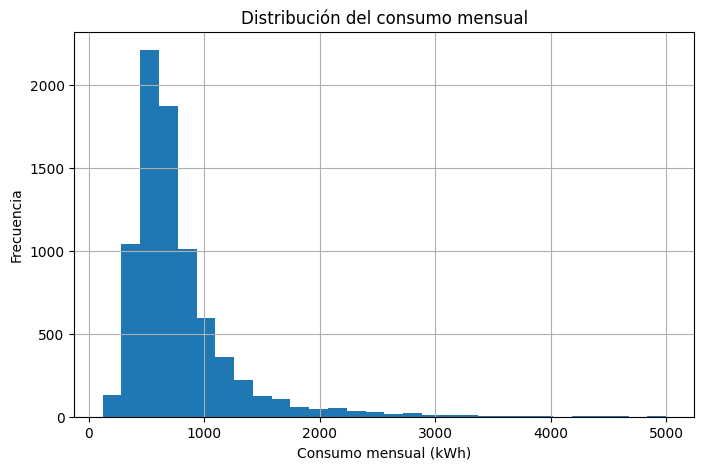

In [68]:
plt.figure(figsize=(8, 5))
df["consumo_kwh"].hist(bins=30)
plt.title("Distribución del consumo mensual")
plt.xlabel("Consumo mensual (kWh)")
plt.ylabel("Frecuencia")
plt.show()


### Distribución de categorías energéticas

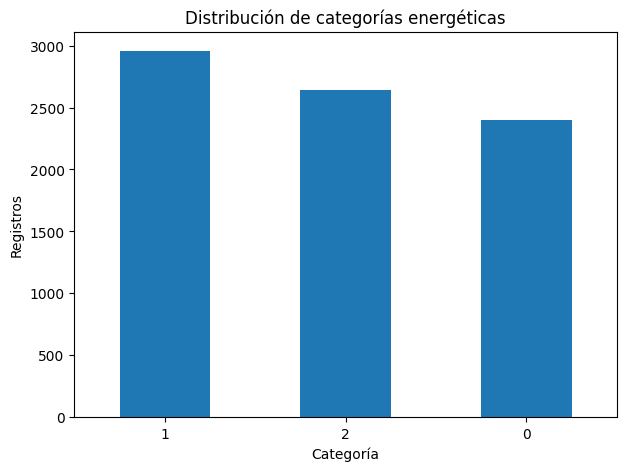

In [69]:
plt.figure(figsize=(7, 5))
df["categoria"].value_counts().plot(kind="bar")
plt.title("Distribución de categorías energéticas")
plt.xlabel("Categoría")
plt.ylabel("Registros")
plt.xticks(rotation=0)
plt.show()


### Consumo promedio por categoría

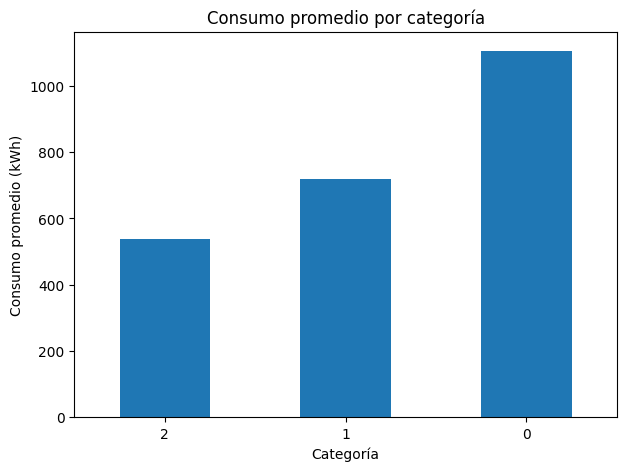

,consumo_kwh
categoria,
2,538.492352
1,717.638443
0,1106.455900


In [70]:
promedio_categoria = (
    df.groupby("categoria", observed=True)["consumo_kwh"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(7, 5))
promedio_categoria.plot(kind="bar")
plt.title("Consumo promedio por categoría")
plt.xlabel("Categoría")
plt.ylabel("Consumo promedio (kWh)")
plt.xticks(rotation=0)
plt.show()

display(promedio_categoria)


## 7. Preparación de variables

Se eliminan `categoria` y `puntaje_ineficiencia` de las variables de entrada.

`puntaje_ineficiencia` no debe usarse para entrenar porque fue empleado para construir la etiqueta. Incluirlo produciría fuga de información.


In [71]:
display(df.head())

,consumo_kwh,uso_horario_pico,cantidad_equipos,tipo_inmueble,horas_alto_consumo,cantidad_personas,area_m2,equipos_alto_consumo,horas_aire_acondicionado,dias_facturados,consumo_por_persona,consumo_por_m2,variacion_mensual,proporcion_equipos_alto_consumo,categoria
0,690.58,False,14,Departamento,5,7,101.0,9,4,30,98.6543,6.8374,-0.1218,0.6429,2
1,461.07,False,6,Casa,4,4,237.0,6,0,28,115.2675,1.9454,-0.1361,1.0000,2
2,454.36,True,27,Pequeno negocio,0,1,103.0,2,5,28,454.3600,4.4113,-0.0593,0.0741,2
3,378.04,False,13,Departamento,1,3,69.0,1,11,31,126.0133,5.4788,0.0761,0.0769,2
4,690.52,False,14,Casa,2,7,298.0,3,3,28,98.6457,2.3172,-0.0504,0.2143,2


### Split

In [72]:
# COLUMNAS_EXCLUIDAS = ["categoria", "puntaje_ineficiencia"]
COLUMNAS_EXCLUIDAS = ["categoria"]
X = df.drop(columns=COLUMNAS_EXCLUIDAS)
y = df["categoria"]

categorical_features = ["tipo_inmueble"]
numeric_features = [
    column for column in X.columns
    if column not in categorical_features
]

# tipo_inmueble, porque es la unica que es texto

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

COLUMNAS_AVANZADAS_MODELO = [
    "cantidad_personas", "area_m2", "equipos_alto_consumo",
    "horas_aire_acondicionado", "dias_facturados",
    "consumo_por_persona", "consumo_por_m2",
    "variacion_mensual", "proporcion_equipos_alto_consumo",
]

def convertir_a_basico(datos):
    basico = datos.copy()
    basico[COLUMNAS_AVANZADAS_MODELO] = np.nan
    return basico

X_train_aumentado = pd.concat(
    [X_train, convertir_a_basico(X_train)], ignore_index=True
)
y_train_aumentado = pd.concat([y_train, y_train], ignore_index=True)
X_test_basico = convertir_a_basico(X_test)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)


Entrenamiento: (6400, 14)
Prueba: (1600, 14)


### pipeline de configuracion para entrenamiento

In [73]:
from sklearn.tree import DecisionTreeClassifier

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

log_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000, class_weight="balanced", random_state=42
            ),
        ),
    ]
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=14,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=10,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

# 4. Transformar los conjuntos de datos (para que el unico dato string lo pueda interpretar como dato numerico)
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [74]:
X_train.head()

,consumo_kwh,uso_horario_pico,cantidad_equipos,tipo_inmueble,horas_alto_consumo,cantidad_personas,area_m2,equipos_alto_consumo,horas_aire_acondicionado,dias_facturados,consumo_por_persona,consumo_por_m2,variacion_mensual,proporcion_equipos_alto_consumo
7176,528.52,True,17,Casa,1,4,276.0,2,6,28,132.1300,1.9149,0.2068,0.1176
5849,506.70,True,18,Departamento,10,1,52.0,8,9,30,506.7000,9.7442,-0.2992,0.4444
5949,521.38,True,15,Departamento,8,1,92.0,7,8,28,521.3800,5.6672,0.0717,0.4667
5023,586.36,True,17,Departamento,8,7,83.0,7,3,29,83.7657,7.0646,-0.1202,0.4118
251,829.69,False,33,Pequeno negocio,12,6,92.0,3,2,30,138.2817,9.0184,-0.0821,0.0909


### Verificar desbalanceamiento

In [75]:
y_train.value_counts(normalize=True) * 100

,proportion
categoria,
1,37.0
2,33.0
0,30.0


# 8. Entrenamiento para análisis

### Modelo 1 — Regresion logistica

In [76]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# 1. Regresión Logística
log_model = LogisticRegression(
    max_iter=1000, class_weight="balanced", random_state=42
)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

=== Reporte de Clasificación - Regresión Logística (Pipeline) ===
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       480
           1       0.67      0.66      0.67       592
           2       0.79      0.80      0.80       528

    accuracy                           0.75      1600
   macro avg       0.76      0.76      0.76      1600
weighted avg       0.75      0.75      0.75      1600



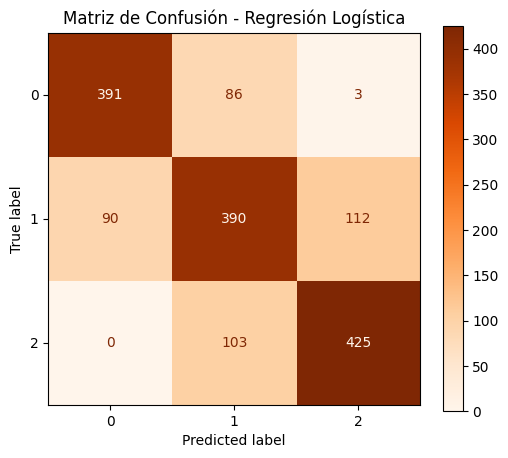

In [77]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.pipeline import Pipeline


log_pipeline.fit(X_train, y_train)

y_pred_log = log_pipeline.predict(X_test)

print("=== Reporte de Clasificación - Regresión Logística (Pipeline) ===")
print(classification_report(y_test, y_pred_log))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_log, cmap="Oranges", ax=ax
)
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

### Modelo 2 — Random Forest

=== Reporte de Clasificación - Random Forest (Pipeline) ===
              precision    recall  f1-score   support

           0       0.78      0.76      0.77       480
           1       0.65      0.67      0.66       592
           2       0.80      0.79      0.79       528

    accuracy                           0.73      1600
   macro avg       0.74      0.74      0.74      1600
weighted avg       0.74      0.73      0.74      1600



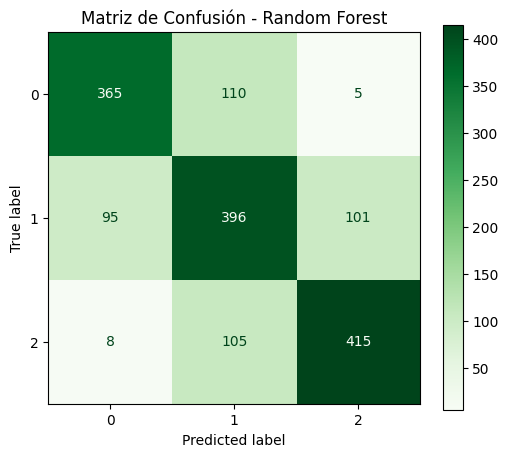

In [78]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.pipeline import Pipeline

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print("=== Reporte de Clasificación - Random Forest (Pipeline) ===")
print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, cmap="Greens", ax=ax
)
plt.title("Matriz de Confusión - Random Forest")
plt.show()

### Modelo 3 — Árbol de Descición



=== Reporte de Clasificación - Árbol de Decisión (Pipeline) ===
              precision    recall  f1-score   support

           0       0.67      0.69      0.68       480
           1       0.52      0.55      0.53       592
           2       0.72      0.66      0.69       528

    accuracy                           0.63      1600
   macro avg       0.64      0.63      0.63      1600
weighted avg       0.63      0.63      0.63      1600



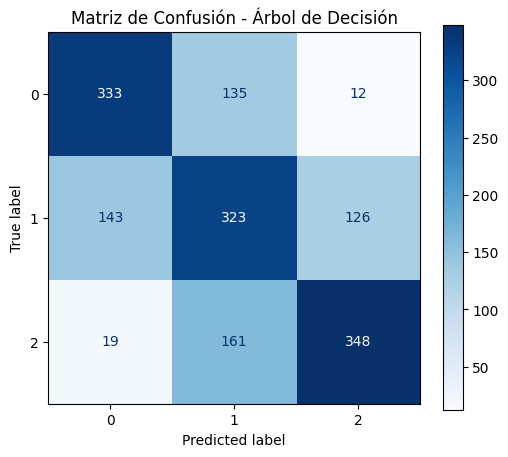

In [79]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

tree_pipeline.fit(X_train, y_train)

y_pred_tree = tree_pipeline.predict(X_test)

print("=== Reporte de Clasificación - Árbol de Decisión (Pipeline) ===")
print(classification_report(y_test, y_pred_tree))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tree, cmap="Blues", ax=ax
)
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.show()

# 9. Modelo ganador

Se comparan dos modelos:

- Regresión logística: línea base.
- Random Forest: candidato principal.
- Árbol de Descición.


In [80]:
modelos = {
    "regresion_logistica": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "arbol_decision": DecisionTreeClassifier(
        max_depth=10,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=14,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

resultados = {}
pipelines = {}

for nombre, modelo in modelos.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", modelo),
        ]
    )

    pipeline.fit(X_train_aumentado, y_train_aumentado)
    predicciones = pipeline.predict(X_test)
    predicciones_basicas = pipeline.predict(X_test_basico)

    resultados[nombre] = {
        "avanzado": {
            "accuracy": accuracy_score(y_test, predicciones),
            "f1_macro": f1_score(y_test, predicciones, average="macro"),
        },
        "basico": {
            "accuracy": accuracy_score(y_test, predicciones_basicas),
            "f1_macro": f1_score(y_test, predicciones_basicas, average="macro"),
        },
    }
    resultados[nombre]["f1_promedio"] = (
        resultados[nombre]["avanzado"]["f1_macro"]
        + resultados[nombre]["basico"]["f1_macro"]
    ) / 2
    pipelines[nombre] = pipeline

tabla_resultados = pd.DataFrame(
    {
        nombre: {
            "accuracy_avanzado": metricas["avanzado"]["accuracy"],
            "f1_macro_avanzado": metricas["avanzado"]["f1_macro"],
            "accuracy_basico": metricas["basico"]["accuracy"],
            "f1_macro_basico": metricas["basico"]["f1_macro"],
            "f1_promedio": metricas["f1_promedio"],
        }
        for nombre, metricas in resultados.items()
    }
).T

display(
    tabla_resultados.sort_values(
        by="f1_promedio",
        ascending=False,
    )
)


,accuracy_avanzado,f1_macro_avanzado,accuracy_basico,f1_macro_basico,f1_promedio
regresion_logistica,0.750000,0.753476,0.662500,0.668246,0.710861
random_forest,0.730625,0.736232,0.669375,0.674984,0.705608
arbol_decision,0.622500,0.628755,0.615000,0.622021,0.625388


## 8. Selección y evaluación detallada


In [81]:
nombre_mejor_modelo = max(
    resultados,
    key=lambda nombre: resultados[nombre]["f1_promedio"],
)

mejor_pipeline = pipelines[nombre_mejor_modelo]
predicciones = mejor_pipeline.predict(X_test)

print("Modelo seleccionado:", nombre_mejor_modelo)
print("Accuracy:", round(accuracy_score(y_test, predicciones), 4))
print("F1 macro:", round(f1_score(y_test, predicciones, average="macro"), 4))
print("\nReporte de clasificación:")
print(classification_report(y_test, predicciones))


Modelo seleccionado: regresion_logistica
Accuracy: 0.75
F1 macro: 0.7535

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.82      0.81       480
           1       0.68      0.63      0.65       592
           2       0.78      0.82      0.80       528

    accuracy                           0.75      1600
   macro avg       0.75      0.76      0.75      1600
weighted avg       0.75      0.75      0.75      1600



## 9. Prueba de predicción


In [82]:
# ejemplo = pd.DataFrame([{
#     "consumo_kwh": 420.0,
#     "uso_horario_pico": True,
#     "cantidad_equipos": 10,
#     "tipo_inmueble": "Casa",
#     "horas_alto_consumo": 8,
#     "cantidad_personas": 4,
#     "area_m2": 120.0,
#     "equipos_alto_consumo": 3,
#     "horas_aire_acondicionado": 5,
#     "consumo_mes_anterior_kwh": 380.0,
#     "dias_facturados": 30,
#     "consumo_diario": 420.0 / 30,
#     "consumo_por_persona": 420.0 / 4,
#     "consumo_por_m2": 420.0 / 120.0,
#     "variacion_mensual": (420.0 - 380.0) / 380.0,
#     "proporcion_equipos_alto_consumo": 3 / 10,
# }])


ejemplo = pd.DataFrame([{
    "consumo_kwh": 420.0,
    "uso_horario_pico": True,
    "cantidad_equipos": 10,
    "tipo_inmueble": "Casa",
    "horas_alto_consumo": 8,
    "cantidad_personas": 4,
    "area_m2": 120.0,
    "equipos_alto_consumo": 3,
    "horas_aire_acondicionado": 5,
    "dias_facturados": 30,
    "consumo_por_persona": 420.0 / 4,
    "consumo_por_m2": 420.0 / 120.0,
    "variacion_mensual": (420.0 - 380.0) / 380.0,
    "proporcion_equipos_alto_consumo": 3 / 10,
}])

categoria = mejor_pipeline.predict(ejemplo)[0]
probabilidades = mejor_pipeline.predict_proba(ejemplo)[0]
clases = mejor_pipeline.named_steps["classifier"].classes_

resultado = {
    "categoria": str(int(categoria)),
    "probabilidad_modelo": round(
        float(probabilidades[list(clases).index(categoria)]),
        4,
    ),
    "probabilidades": {
        clase: round(float(probabilidad), 4)
        for clase, probabilidad in zip(clases, probabilidades)
    },
    "costo_estimado_mensual": round(420.0 * 0.75, 2),
    "tarifa_kwh": 0.75,
    "moneda": "BRL",
}

resultado


{'categoria': '1',
 'probabilidad_modelo': 0.5093,
 'probabilidades': {np.int64(0): 0.0824,
  np.int64(1): 0.5093,
  np.int64(2): 0.4084},
 'costo_estimado_mensual': 315.0,
 'tarifa_kwh': 0.75,
 'moneda': 'BRL'}

## 10. Exportación del modelo

Se guarda el pipeline completo para conservar exactamente el mismo preprocesamiento durante la inferencia.


In [83]:
joblib.dump(mejor_pipeline, MODEL_PATH)

metadata = {
    "nombre": "clasificador-energia",
    "version": "1.1.0",
    "modelo_seleccionado": nombre_mejor_modelo,
    "metricas": resultados[nombre_mejor_modelo]["avanzado"],
    "metricas_basicas": resultados[nombre_mejor_modelo]["basico"],
    "f1_promedio": resultados[nombre_mejor_modelo]["f1_promedio"],
    "columnas_entrada": list(X.columns),
    "categorias": list(
        mejor_pipeline.named_steps["classifier"].classes_.tolist()
    ),
    "mapeo_categorias": {
        str(codigo): nombre
        for codigo, nombre in MAPEO_CATEGORIAS_INVERSO.items()
    },
    "rango_consumo_kwh_entrenamiento": {
        "minimo": float(X["consumo_kwh"].min()),
        "maximo": float(X["consumo_kwh"].max()),
    },
    "limites_api_consumo_kwh": {"minimo_exclusivo": 0, "maximo": 5000},
    "entrenado_para_nivel_basico": True,
    "tarifa_kwh": 0.75,
    "moneda": "BRL",
}

with open(METADATA_PATH, "w", encoding="utf-8") as archivo:
    json.dump(metadata, archivo, indent=2, ensure_ascii=False)

print("Modelo guardado en:", MODEL_PATH)
print("Metadatos guardados en:", METADATA_PATH)


Modelo guardado en: /content/drive/MyDrive/Notebook Hackathon /analisis-de-energia/models/modelo_energia.joblib
Metadatos guardados en: /content/drive/MyDrive/Notebook Hackathon /analisis-de-energia/models/metadata_modelo.json


## 11. Verificación después de cargar

Esta prueba confirma que el archivo exportado puede utilizarse fuera del entrenamiento.


In [84]:
modelo_cargado = joblib.load(MODEL_PATH)

prediccion_recargada = modelo_cargado.predict(ejemplo)[0]
probabilidades_recargadas = modelo_cargado.predict_proba(ejemplo)[0]

print("Categoría:", prediccion_recargada)
print("Probabilidades:", probabilidades_recargadas)


Categoría: 1
Probabilidades: [0.0823534  0.50925805 0.40838855]


## Criterio de finalización

El análisis queda listo cuando:

- El dataset se genera sin errores.
- No existen valores fuera de rango.
- Las tres categorías tienen registros suficientes.
- Se comparan al menos dos modelos.
- Se presenta `F1 macro`.
- Se presenta una matriz de confusión.
- El pipeline se guarda como `modelo_energia.joblib`.
- El modelo puede cargarse y predecir después de ser serializado.


In [85]:
print("=== VERIFICACIÓN FINAL ===")

print(
    "Dataset generado:",
    "APROBADO" if DATASET_PATH.exists() else "PENDIENTE"
)

print(
    "Sin valores nulos:",
    "APROBADO" if df.isnull().sum().sum() == 0 else "PENDIENTE"
)

print(
    "Tres categorías:",
    "APROBADO"
    if set(df["categoria"].unique()) == {0, 1, 2}
    else "PENDIENTE"
)

print(
    "Dos modelos comparados:",
    "APROBADO" if len(resultados) >= 2 else "PENDIENTE"
)

print(
    "F1 macro:",
    round(resultados[nombre_mejor_modelo]["f1_promedio"], 4)
)

print(
    "Modelo guardado:",
    "APROBADO" if MODEL_PATH.exists() else "PENDIENTE"
)

try:
    modelo_prueba = joblib.load(MODEL_PATH)
    ejemplo_prueba = X_test.iloc[[0]]
    resultado_prueba = modelo_prueba.predict(ejemplo_prueba)[0]

    print("Modelo cargado: APROBADO")
    print("Predicción después de cargar:", resultado_prueba)

except Exception as error:
    print("Modelo cargado: PENDIENTE")
    print("Error:", error)

=== VERIFICACIÓN FINAL ===
Dataset generado: APROBADO
Sin valores nulos: APROBADO
Tres categorías: APROBADO
Dos modelos comparados: APROBADO
F1 macro: 0.7109
Modelo guardado: APROBADO
Modelo cargado: APROBADO
Predicción después de cargar: 2


In [86]:
import pandas
import sklearn
import joblib
import pydantic

print("pandas:", pandas.__version__)
print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)
print("pydantic:", pydantic.__version__)

pandas: 2.2.2
scikit-learn: 1.6.1
joblib: 1.5.3
pydantic: 2.13.4
